In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import zscore

In [2]:
df = pd.read_csv('../data/kenya.csv', encoding='latin1', skiprows=[1])
df['Country'] = 'Kenya'
print(df.shape)
df.head()

(4107, 13)


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
0,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85,Kenya
1,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65,Kenya
2,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60,Kenya
3,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64,Kenya
4,2015,6,20.89,29.94,12.47,17.47,0.01,53.78,2.73,4.00,83.63,9.05,Kenya


In [3]:
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df['MONTH'] = df['Date'].dt.month
df.tail()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,MONTH
4102,2026,86,19.37,25.40,15.39,10.01,2.67,81.97,2.47,3.90,84.08,13.40,Kenya,2026-03-27,3
4103,2026,87,19.66,26.40,15.24,11.16,0.59,77.40,1.98,3.37,84.02,12.68,Kenya,2026-03-28,3
4104,2026,88,19.72,26.54,14.41,12.13,0.82,77.71,1.77,3.25,83.88,12.92,Kenya,2026-03-29,3
4105,2026,89,19.68,26.81,13.86,12.95,4.59,79.29,2.01,3.32,83.87,13.16,Kenya,2026-03-30,3
4106,2026,90,19.59,25.54,15.37,10.17,1.29,80.88,2.15,3.58,83.92,13.40,Kenya,2026-03-31,3


In [4]:
# Check for missing values and duplicates(-999 is NASA's sentinel value for missing or out-of-range data.)
df = df.replace(-999, np.nan)
print("Number of duplicate rows found:", df.duplicated().sum())
df = df.drop_duplicates()

Number of duplicate rows found: 0


No duplicate rows were found and removed using drop_duplicates().
Duplicates were exact row-level repeats across all columns (no partial column-specific duplicates detected).

In [5]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,MONTH
count,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107,4107.000000
mean,2020.132700,180.164841,20.427811,27.838437,14.673798,13.164638,1.468520,65.850353,3.061751,4.375147,83.724346,11.053555,2020-08-16 00:00:00,6.424884
min,2015.000000,1.000000,15.260000,18.880000,8.970000,4.110000,0.000000,28.420000,0.610000,1.160000,83.310000,4.780000,2015-01-02 00:00:00,1.000000
25%,2017.000000,86.000000,19.460000,26.295000,13.700000,11.465000,0.100000,58.685000,2.420000,3.670000,83.630000,9.880000,2017-10-24 12:00:00,3.000000
50%,2020.000000,179.000000,20.360000,27.870000,14.750000,13.260000,0.380000,66.230000,3.140000,4.430000,83.720000,11.010000,2020-08-16 00:00:00,6.000000
75%,2023.000000,272.000000,21.400000,29.520000,15.750000,15.050000,1.360000,73.280000,3.720000,5.090000,83.810000,12.350000,2023-06-08 12:00:00,9.000000
max,2026.000000,366.000000,25.400000,34.270000,18.750000,20.120000,51.650000,91.070000,5.280000,7.590000,84.170000,15.040000,2026-03-31 00:00:00,12.000000
std,3.248315,106.270943,1.440936,2.358989,1.415289,2.604839,3.180533,9.930239,0.853321,0.992258,0.126405,1.606027,NaN,3.476439


### Interpretation of Descriptive Statistics

The dataset contains 4,107 observations.

Temperature variables (T2M, T2M_MAX, T2M_MIN) show a moderate and consistent distribution. The mean (≈20.43°C) is very close to the median (20.36°C), suggesting a symmetric distribution with no strong skewness. Compared to earlier results, the temperature range is slightly higher, indicating warmer conditions in this dataset.

Precipitation (PRECTOTCORR) remains highly skewed, with a low median (0.38) and a much higher maximum value (51.65). This indicates that most days have little rainfall, but occasional extreme precipitation events occur.

Relative humidity (RH2M) has a mean of about 65.85% and shows less variability than before, suggesting more stable atmospheric moisture conditions.

Wind speed (WS2M) and maximum wind speed (WS2M_MAX) show moderate variability, with slightly higher averages compared to the previous dataset, indicating somewhat stronger wind conditions.

Surface pressure (PS) remains very stable, with minimal variation, which is typical for atmospheric pressure data.

Specific humidity (QV2M) also shows moderate variability and aligns with relative humidity trends.

Overall, the cleaned dataset maintains consistent climate patterns, with reduced noise and improved data reliability after preprocessing. Extreme values in precipitation and wind still exist and likely represent real environmental events rather than errors.

In [6]:
df.isna().sum() 
missing_percent = (df.isna().sum() / len(df)) * 100
print(missing_percent)

YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
Country        0.0
Date           0.0
MONTH          0.0
dtype: float64


In [7]:
cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

z_scores = df[cols].apply(zscore)
outliers = (np.abs(z_scores) > 3)
outlier_rows = outliers.any(axis=1).sum()
print("Number of rows with extreme values (|Z| > 3):", outlier_rows)

Number of rows with extreme values (|Z| > 3): 120


#Number of rows with extreme values (|Z| > 3): 120
### Z-Score Outlier Analysis
Rows with absolute Z-scores greater than 3 were flagged as potential outliers, indicating unusually extreme weather conditions compared to the dataset distribution.

The analysis identified 120 rows containing at least one extreme value. These outliers may correspond to rare weather events such as heatwaves, heavy rainfall, or unusually strong winds.

Such extreme values are important in climate analysis and should not be automatically removed, as they may represent meaningful environmental phenomena rather than data errors.

In [8]:
# Forward-fill weather-related columns
weather_cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]
df[weather_cols] = df[weather_cols].ffill()
threshold = int(0.7 * df.shape[1])  # keep rows with at least 70% non-null values
df = df.dropna(thresh=threshold)


### Missing Value Handling

Missing values were handled using a combination of forward-fill imputation and row removal.

Forward-fill was applied to key weather variables (temperature, precipitation, humidity, and wind speed) to preserve temporal continuity in the dataset. This method assumes that short gaps in measurements can be reasonably approximated using the most recent valid observation.

Additionally, rows with more than 30% missing values were removed to ensure data quality and reliability. This prevents heavily incomplete records from skewing analysis.

In this dataset, no missing values remained after initial preprocessing, so these steps served as a precautionary measure to ensure robustness.

In [9]:
df.to_csv("../data/kenya_clean.csv", index=False)

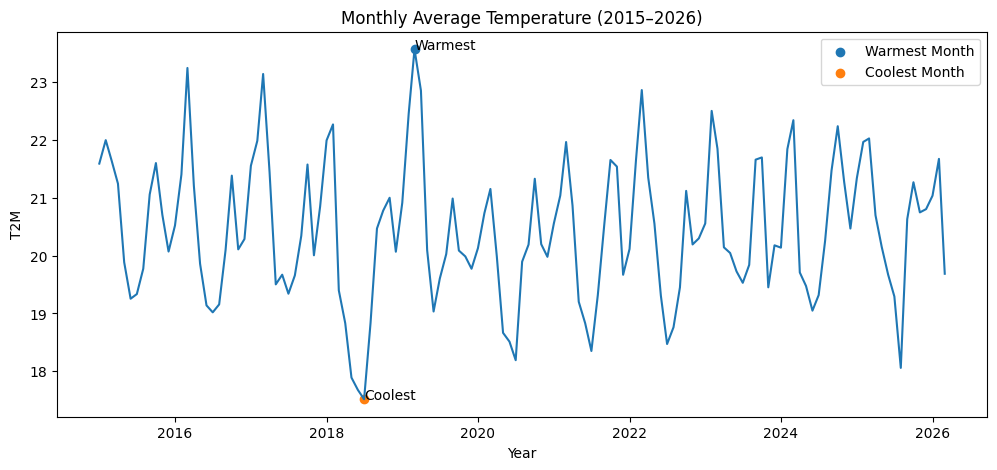

In [10]:
mon_AT2M = df.groupby(["YEAR", "MONTH"])["T2M"].mean().reset_index()

mon_AT2M["Date"] = pd.to_datetime(
    mon_AT2M["YEAR"].astype(str) + "-" + mon_AT2M["MONTH"].astype(str)
)

plt.figure(figsize=(12,5))
plt.plot(mon_AT2M["Date"], mon_AT2M["T2M"])

# warmest / coolest
warmest = mon_AT2M.loc[mon_AT2M["T2M"].idxmax()]
coolest = mon_AT2M.loc[mon_AT2M["T2M"].idxmin()]

plt.scatter(warmest["Date"], warmest["T2M"], label="Warmest Month")
plt.scatter(coolest["Date"], coolest["T2M"], label="Coolest Month")

plt.annotate("Warmest", (warmest["Date"], warmest["T2M"]))
plt.annotate("Coolest", (coolest["Date"], coolest["T2M"]))

plt.title("Monthly Average Temperature (2015–2026)")
plt.xlabel("Year")
plt.ylabel("T2M")
plt.legend()
plt.show()

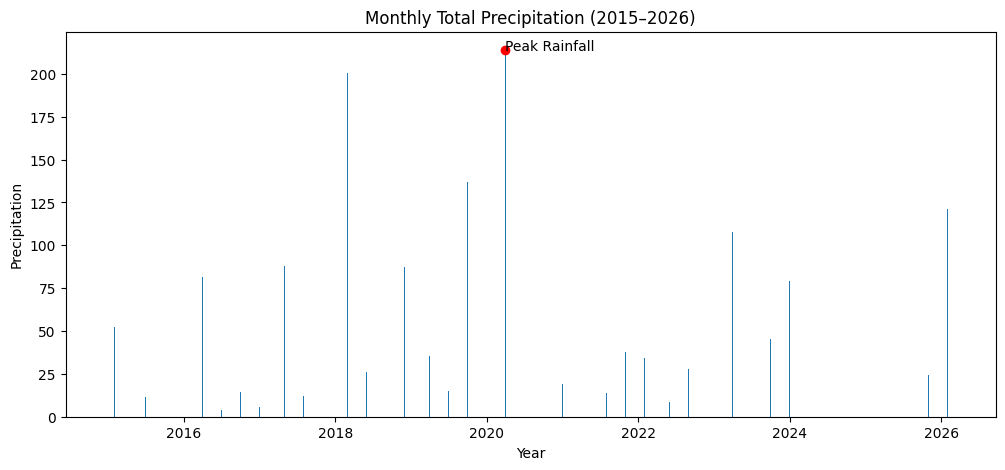

In [11]:

mon_rain = df.groupby(["YEAR", "MONTH"])["PRECTOTCORR"].sum().reset_index()

mon_rain["Date"] = pd.to_datetime(
    mon_rain["YEAR"].astype(str) + "-" + mon_rain["MONTH"].astype(str)
)

plt.figure(figsize=(12,5))
plt.bar(mon_rain["Date"], mon_rain["PRECTOTCORR"])

peak = mon_rain.loc[mon_rain["PRECTOTCORR"].idxmax()]

plt.scatter(peak["Date"], peak["PRECTOTCORR"], color="red")
plt.annotate("Peak Rainfall", (peak["Date"], peak["PRECTOTCORR"]))

plt.title("Monthly Total Precipitation (2015–2026)")
plt.xlabel("Year")
plt.ylabel("Precipitation")
plt.show()

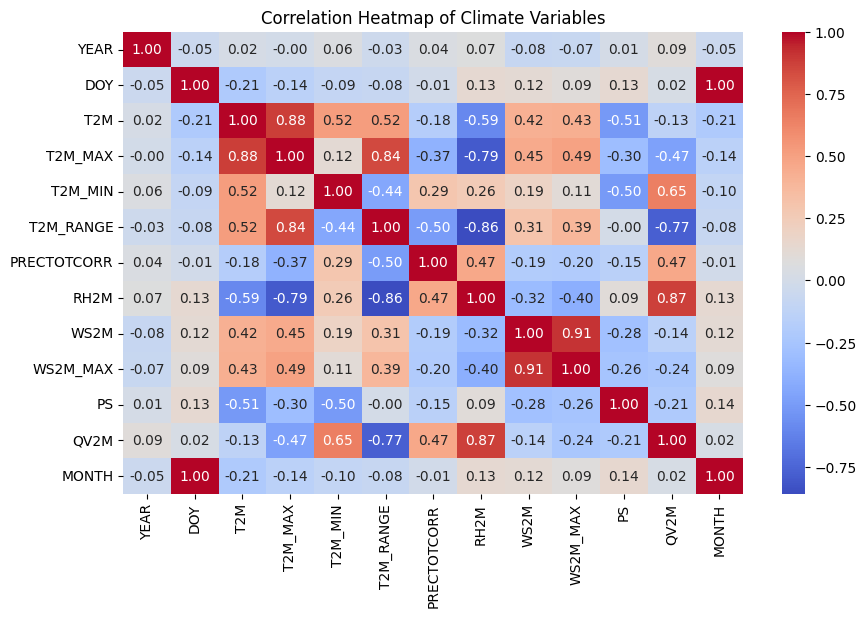

In [12]:

###Correlation heatmap
numeric_df = df.select_dtypes(include="number")

corr = numeric_df.corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap of Climate Variables")
plt.show()

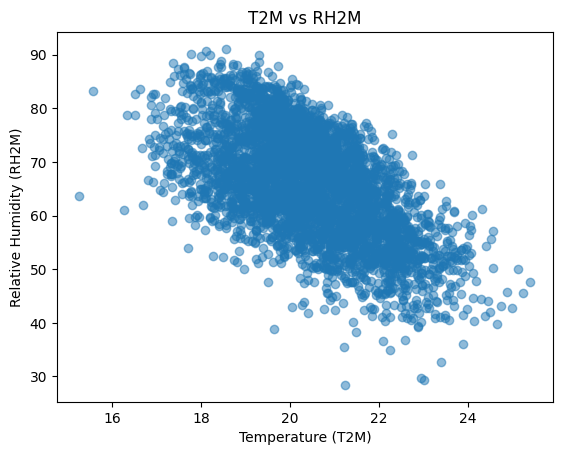

In [13]:
###Scatter plot of T2M vs RH2M

plt.figure()

plt.scatter(df["T2M"], df["RH2M"], alpha=0.5)

plt.title("T2M vs RH2M")
plt.xlabel("Temperature (T2M)")
plt.ylabel("Relative Humidity (RH2M)")

plt.show()

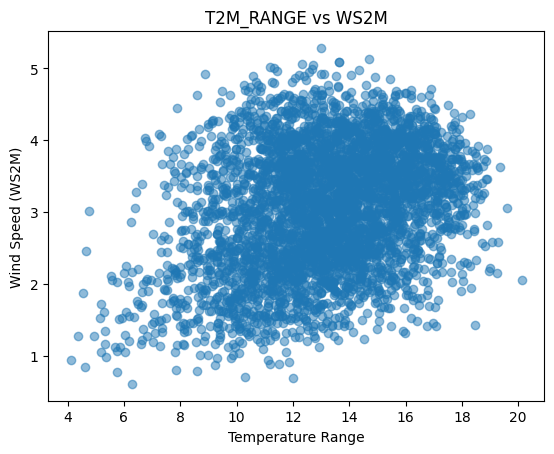

In [14]:
###Scatter plot of T2M_RANGE vs WS2M

plt.figure()

plt.scatter(df["T2M_RANGE"], df["WS2M"], alpha=0.5)

plt.title("T2M_RANGE vs WS2M")
plt.xlabel("Temperature Range")
plt.ylabel("Wind Speed (WS2M)")

plt.show()

In [15]:
###Identify the strongest correlations (positive and negative)
corr_pairs = corr.unstack().sort_values(ascending=False)

# remove self-correlation (1.0)
corr_pairs = corr_pairs[corr_pairs < 1]

print(corr_pairs.head(10))

DOY        MONTH        0.996557
MONTH      DOY          0.996557
WS2M_MAX   WS2M         0.911468
WS2M       WS2M_MAX     0.911468
T2M_MAX    T2M          0.881043
T2M        T2M_MAX      0.881043
QV2M       RH2M         0.869405
RH2M       QV2M         0.869405
T2M_RANGE  T2M_MAX      0.841931
T2M_MAX    T2M_RANGE    0.841931
dtype: float64
